# NN_08 — Comparação de Arquiteturas em Variantes Comuns (tau e z_eq)

## Objetivo

Este notebook implementa o plano revisado de comparação justa entre arquiteturas, mantendo as variantes de entrada fixas. A análise é organizada em duas famílias de variantes: a família **tau** (V5, V6, V7, V8, V1) vinda do NN_02b e a família **z_eq** (A, B, C, D) vinda do NN_02c. Para cada variante, a comparação entre arquiteturas/classificadores deve ocorrer sobre a mesma definição de entrada, evitando confusão entre ganho de arquitetura e ganho de feature engineering.

## Escopo desta versão

Esta versão consolida resultados já executados e prepara a matriz comparativa para expansão com novos classificadores. Os valores preenchidos automaticamente vêm de NN_02b, NN_02c e NN_07 (D3F com $\alpha=10^{-7}$). As demais arquiteturas ficam explicitamente marcadas como pendentes para execução futura no mesmo protocolo.

## Regra metodológica

A comparação é válida apenas quando a variante é fixa e apenas a arquitetura muda. Isso preserva a interpretação causal dos resultados e mantém aderência ao plano experimental definido para a dissertação.

In [9]:
# ==============================================================================
# 1. IMPORTS E CONFIGURAÇÃO
# ==============================================================================
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
results_dir = project_root / "results"
data_dir = results_dir / "data"
models_dir = results_dir / "models"
visualizations_dir = results_dir / "visualizations"
visualizations_dir.mkdir(parents=True, exist_ok=True)

ALPHA = 1e-7
SNR_BINS = [0, 5, 10, 15, 20, 25, 30]

print("Configuração carregada.")
print(f"project_root: {project_root}")
print(f"alpha D3F: {ALPHA:.0e}")

Configuração carregada.
project_root: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais
alpha D3F: 1e-07


In [10]:
# ==============================================================================
# 2. CARREGAR RESULTADOS JÁ EXECUTADOS (NN_02b, NN_02c, NN_07)
# ==============================================================================
path_02b = data_dir / "nn02b_ablation_results.json"
path_02c = models_dir / "nn02c_ablation_results.json"
path_07 = data_dir / "nn07_unified_comparison.json"

with open(path_02b, "r") as f:
    res_02b = json.load(f)
with open(path_02c, "r") as f:
    res_02c = json.load(f)
with open(path_07, "r") as f:
    res_07 = json.load(f)

print("Arquivos carregados com sucesso:")
print(f"  - {path_02b.name}")
print(f"  - {path_02c.name}")
print(f"  - {path_07.name}")

print("\nMétodos presentes em NN_07:")
for k in res_07["methods"].keys():
    print(f"  {k}")

Arquivos carregados com sucesso:
  - nn02b_ablation_results.json
  - nn02c_ablation_results.json
  - nn07_unified_comparison.json

Métodos presentes em NN_07:
  Clássico
  V5 [|τ|]
  z_eq CNN (Var A)
  V7 [|τ|, SNR̄]
  V6 [|τ|, ĥ]
  V8 [|τ|, E] ★
  V1 [4-feat]
  V2 h perfeito
  V3 sem SNR
  V4 sem E
  z_eq+h (Var B)
  z_eq+h+SNR (Var C)
  z_eq+τ (Var D)


In [11]:
# ==============================================================================
# 3. DEFINIR PLANO COMPARATIVO POR VARIANTE FIXA
# ==============================================================================
variant_catalog = [
    {"family": "tau", "variant": "V5", "feature_set": "[|tau|]"},
    {"family": "tau", "variant": "V6", "feature_set": "[|tau|, h_hat]"},
    {"family": "tau", "variant": "V7", "feature_set": "[|tau|, h_hat, SNR_bar]"},
    {"family": "tau", "variant": "V8", "feature_set": "[|tau|, h_hat, E]"},
    {"family": "tau", "variant": "V1", "feature_set": "[|tau|, h_hat, SNR_bar, E]"},
    {"family": "z_eq", "variant": "A", "feature_set": "z_eq[1024]"},
    {"family": "z_eq", "variant": "B", "feature_set": "z_eq[1024] + h"},
    {"family": "z_eq", "variant": "C", "feature_set": "z_eq[1024] + h + SNR"},
    {"family": "z_eq", "variant": "D", "feature_set": "z_eq[1024] + |tau|"},
]

architectures_plan = {
    "tau": ["DNN", "SVM-RBF", "KNN-5", "XGBoost"],
    "z_eq": ["CNN-1D", "MLP", "SVM-RBF", "XGBoost"],
}

catalog_df = pd.DataFrame(variant_catalog)
print("Catálogo de variantes definido:")
display(catalog_df)

print("\nArquiteturas planejadas por família:")
for fam, archs in architectures_plan.items():
    print(f"  {fam}: {', '.join(archs)}")

Catálogo de variantes definido:


,family,variant,feature_set
0,tau,V5,[|tau|]
1,tau,V6,"[|tau|, h_hat]"
2,tau,V7,"[|tau|, h_hat, SNR_bar]"
3,tau,V8,"[|tau|, h_hat, E]"
4,tau,V1,"[|tau|, h_hat, SNR_bar, E]"
5,z_eq,A,z_eq[1024]
6,z_eq,B,z_eq[1024] + h
7,z_eq,C,z_eq[1024] + h + SNR
8,z_eq,D,z_eq[1024] + |tau|



Arquiteturas planejadas por família:
  tau: DNN, SVM-RBF, KNN-5, XGBoost
  z_eq: CNN-1D, MLP, SVM-RBF, XGBoost


In [12]:
# ==============================================================================
# 4. MATRIZ BASELINE (RESULTADOS JÁ DISPONÍVEIS)
# ==============================================================================

def pd0_from_series(series_dict):
    return float(series_dict.get("0", np.nan))

rows = []

# Baselines da família tau (NN_02b: arquitetura DNN)
map_02b = {
    "V5": "V5_tau_only",
    "V6": "V6_tau_h",
    "V7": "V7_h_snr",
    "V8": "V8_h_energy",
    "V1": "V1_baseline",
}
for v, key in map_02b.items():
    pd_map = res_02b["variants"][key]["pd_vs_snr"]
    rows.append({
        "family": "tau",
        "variant": v,
        "architecture": "DNN",
        "pd_0db": float(pd_map["0"]),
        "pd_5db": float(pd_map["5"]),
        "source": "NN_02b",
        "status": "executado",
    })

# Baselines da família z_eq (NN_02c: arquitetura CNN-1D)
for v in ["A", "B", "C", "D"]:
    pd_map = res_02c["variants"][v]["pd_d3f"]
    rows.append({
        "family": "z_eq",
        "variant": v,
        "architecture": "CNN-1D",
        "pd_0db": float(pd_map["0"]),
        "pd_5db": float(pd_map["5"]),
        "source": "NN_02c",
        "status": "executado",
    })

baseline_df = pd.DataFrame(rows)
print("Baseline executado (parcial da matriz do plano NN_08):")
display(baseline_df.sort_values(["family", "variant"]))

Baseline executado (parcial da matriz do plano NN_08):


,family,variant,architecture,pd_0db,pd_5db,source,status
4,tau,V1,DNN,0.836974,0.994295,NN_02b,executado
0,tau,V5,DNN,0.000000,0.989627,NN_02b,executado
1,tau,V6,DNN,0.846564,0.995591,NN_02b,executado
2,tau,V7,DNN,0.820458,0.995073,NN_02b,executado
3,tau,V8,DNN,0.816196,0.995073,NN_02b,executado
5,z_eq,A,CNN-1D,0.004262,0.000519,NN_02c,executado
6,z_eq,B,CNN-1D,0.001598,0.000519,NN_02c,executado
7,z_eq,C,CNN-1D,0.000000,0.000000,NN_02c,executado
8,z_eq,D,CNN-1D,0.883324,0.996888,NN_02c,executado


In [13]:
# ==============================================================================
# 5. GERAR GRADE COMPLETA DO PLANO (EXECUTADO + PENDENTE)
# ==============================================================================

plan_rows = []
for item in variant_catalog:
    fam = item["family"]
    var = item["variant"]
    for arch in architectures_plan[fam]:
        hit = baseline_df[(baseline_df["family"] == fam) &
                          (baseline_df["variant"] == var) &
                          (baseline_df["architecture"] == arch)]
        if len(hit) > 0:
            rec = hit.iloc[0].to_dict()
        else:
            rec = {
                "family": fam,
                "variant": var,
                "architecture": arch,
                "pd_0db": np.nan,
                "pd_5db": np.nan,
                "source": "-",
                "status": "pendente",
            }
        rec["feature_set"] = item["feature_set"]
        plan_rows.append(rec)

plan_df = pd.DataFrame(plan_rows)
plan_df = plan_df[["family", "variant", "feature_set", "architecture", "pd_0db", "pd_5db", "status", "source"]]

print("Matriz completa do plano NN_08:")
display(plan_df.sort_values(["family", "variant", "architecture"]))

print("\nResumo de cobertura:")
print(plan_df.groupby(["family", "status"]).size().rename("n").reset_index())

Matriz completa do plano NN_08:


,family,variant,feature_set,architecture,pd_0db,pd_5db,status,source
16,tau,V1,"[|tau|, h_hat, SNR_bar, E]",DNN,0.836974,0.994295,executado,NN_02b
18,tau,V1,"[|tau|, h_hat, SNR_bar, E]",KNN-5,NaN,NaN,pendente,-
17,tau,V1,"[|tau|, h_hat, SNR_bar, E]",SVM-RBF,NaN,NaN,pendente,-
19,tau,V1,"[|tau|, h_hat, SNR_bar, E]",XGBoost,NaN,NaN,pendente,-
0,tau,V5,[|tau|],DNN,0.000000,0.989627,executado,NN_02b
2,tau,V5,[|tau|],KNN-5,NaN,NaN,pendente,-
1,tau,V5,[|tau|],SVM-RBF,NaN,NaN,pendente,-
3,tau,V5,[|tau|],XGBoost,NaN,NaN,pendente,-
4,tau,V6,"[|tau|, h_hat]",DNN,0.846564,0.995591,executado,NN_02b
6,tau,V6,"[|tau|, h_hat]",KNN-5,NaN,NaN,pendente,-



Resumo de cobertura:
  family     status   n
0    tau  executado   5
1    tau   pendente  15
2   z_eq  executado   4
3   z_eq   pendente  12


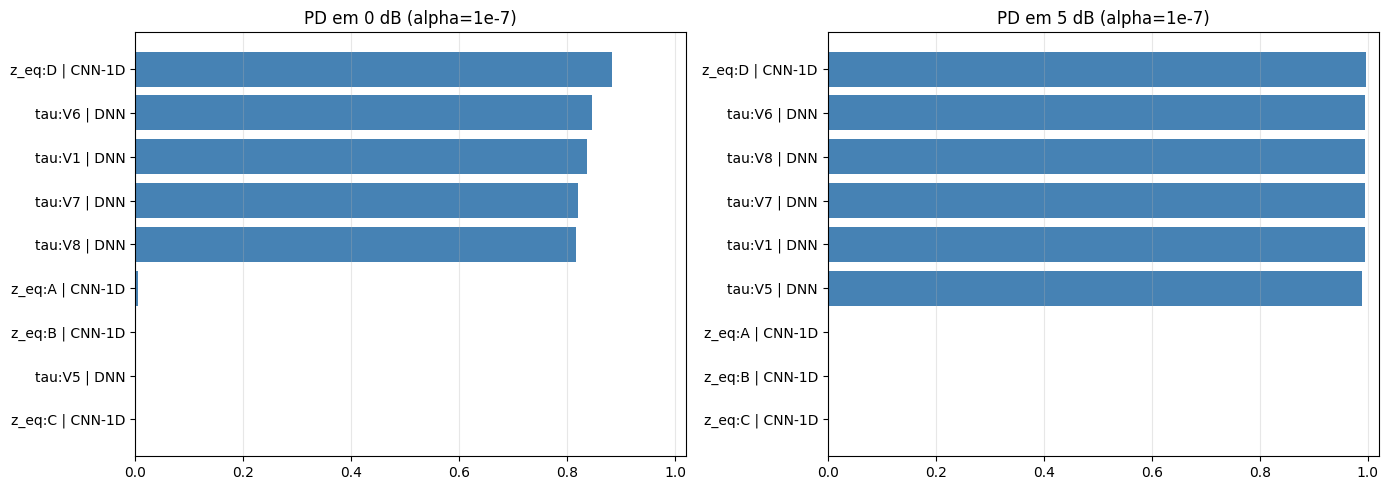

Figura salva: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/visualizations/NN08_plan_baseline_pd_comparison.png


In [14]:
# ==============================================================================
# 6. VISUALIZAÇÕES COMPARATIVAS (0 dB e 5 dB)
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], "pd_0db", "PD em 0 dB (alpha=1e-7)"),
    (axes[1], "pd_5db", "PD em 5 dB (alpha=1e-7)"),
]:
    plot_df = plan_df.dropna(subset=[col]).copy()
    if len(plot_df) == 0:
        ax.set_title(title)
        ax.text(0.5, 0.5, "Sem dados executados", ha="center", va="center")
        ax.axis("off")
        continue
    plot_df["label"] = plot_df["family"] + ":" + plot_df["variant"] + " | " + plot_df["architecture"]
    plot_df = plot_df.sort_values(col, ascending=False)
    ax.barh(plot_df["label"], plot_df[col], color="steelblue")
    ax.invert_yaxis()
    ax.set_xlim(0, 1.02)
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
fig_path = visualizations_dir / "NN08_plan_baseline_pd_comparison.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Figura salva: {fig_path}")

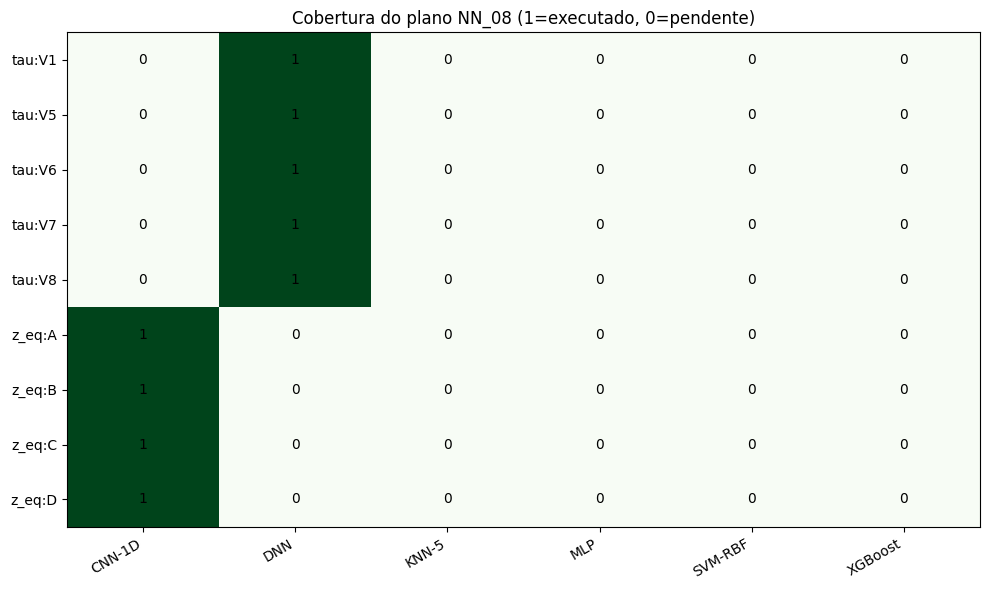

Heatmap salvo: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/visualizations/NN08_plan_coverage_heatmap.png


In [15]:
# ==============================================================================
# 7. HEATMAP DE COBERTURA DO PLANO (EXECUTADO VS PENDENTE)
# ==============================================================================

coverage = plan_df.copy()
coverage["executado"] = (coverage["status"] == "executado").astype(int)

pivot_cov = coverage.pivot_table(
    index=["family", "variant"],
    columns="architecture",
    values="executado",
    aggfunc="max",
    fill_value=0,
)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot_cov.values, aspect="auto", cmap="Greens", vmin=0, vmax=1)

ax.set_xticks(np.arange(len(pivot_cov.columns)))
ax.set_xticklabels(pivot_cov.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(len(pivot_cov.index)))
ax.set_yticklabels([f"{i[0]}:{i[1]}" for i in pivot_cov.index])
ax.set_title("Cobertura do plano NN_08 (1=executado, 0=pendente)")

for i in range(pivot_cov.shape[0]):
    for j in range(pivot_cov.shape[1]):
        val = int(pivot_cov.values[i, j])
        ax.text(j, i, str(val), ha="center", va="center", color="black")

plt.tight_layout()
cov_path = visualizations_dir / "NN08_plan_coverage_heatmap.png"
plt.savefig(cov_path, dpi=150)
plt.show()
print(f"Heatmap salvo: {cov_path}")

In [16]:
# ==============================================================================
# 8. EXPORTAR MATRIZ DO PLANO NN_08
# ==============================================================================

out_json = data_dir / "nn08_architecture_plan_matrix.json"
out_csv  = data_dir / "nn08_architecture_plan_matrix.csv"

payload = {
    "metadata": {
        "alpha": ALPHA,
        "snr_bins": SNR_BINS,
        "sources": [path_02b.name, path_02c.name, path_07.name],
        "description": "Plano NN_08 por variantes fixas (tau e z_eq) com comparação entre arquiteturas",
    },
    "architectures_plan": architectures_plan,
    "records": plan_df.to_dict(orient="records"),
}

with open(out_json, "w") as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)

plan_df.to_csv(out_csv, index=False)

print(f"Plano exportado em JSON: {out_json}")
print(f"Plano exportado em CSV : {out_csv}")

Plano exportado em JSON: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/data/nn08_architecture_plan_matrix.json
Plano exportado em CSV : /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/data/nn08_architecture_plan_matrix.csv
